# Chapter 7: Unsupervised Learning
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(ca)
library(cluster)
library(ellipse)
library(ggrepel)
library(mclust)
library(tidyclust)
library(tidymodels)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'



Attaching package: ‘ellipse’




The following object is masked from ‘package:graphics’:

    pairs




Loading required package: ggplot2



Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.




Attaching package: ‘tidyclust’




...

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──



✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ dplyr        1.2.1      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 
✔ recipes      1.3.2      



── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ dplyr::count()              masks mclust::count()
✖ purrr::discard()            masks scales::discard()
✖ dplyr::filter()             masks stats::filter()
✖ parsnip::knit_engine_docs() masks tidyclust::knit_engine_docs()
✖ dplyr::lag()                masks stats::lag()
✖ parsnip::list_md_problems() masks tidyclust::list_md_problems()
✖ purrr::map()                masks mclust::map()
✖ recipes::step()             masks stats::step()



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ readr     2.2.0     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ dplyr::count()      masks mclust::count()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ stringr::fixed()    masks recipes::fixed()
✖ dplyr::lag()        masks stats::lag()
✖ purrr::map()        masks mclust::map()
✖ readr::spec()       masks yardstick::spec()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Unsupervised Learning
### Principal Components Analysis
#### A Simple Example

In [1]:
sp500_px <- read_csv(file.path(DATA_DIR, "sp500_data.csv.gz"), show_col_types = FALSE)

oil_px <- sp500_px[, c("CVX", "XOM")]
pca <- princomp(oil_px)
pca$loadings


Loadings:
    Comp.1 Comp.2
CVX  0.747  0.665
XOM  0.665 -0.747

               Comp.1 Comp.2
SS loadings       1.0    1.0
Proportion Var    0.5    0.5
Cumulative Var    0.5    1.0

In [1]:
pca_rec <- recipe(data = sp500_px, formula = ~ CVX + XOM) %>%
  step_pca(all_numeric_predictors())
pca_prep <- pca_rec %>%
  prep()
pca_prep$steps[[1]]$rotation

NULL

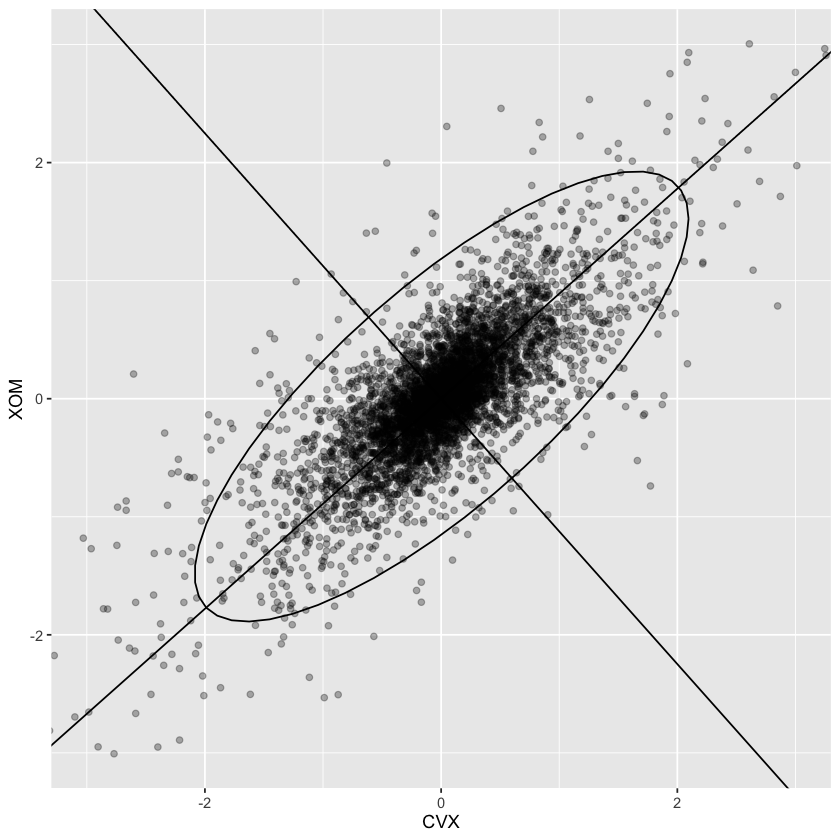

In [1]:
loadings <- pca$loadings
ggplot(data = oil_px, aes(x = CVX, y = XOM)) +
  geom_point(alpha = 0.3) +
  stat_ellipse(type = "norm", level = 0.99) +
  geom_abline(intercept = 0, slope = loadings[2, 1] / loadings[1, 1]) +
  geom_abline(intercept = 0, slope = loadings[2, 2] / loadings[1, 2]) +
  coord_cartesian(xlim = c(-3, 3), ylim = c(-3, 3))

#### Interpreting Principal Components

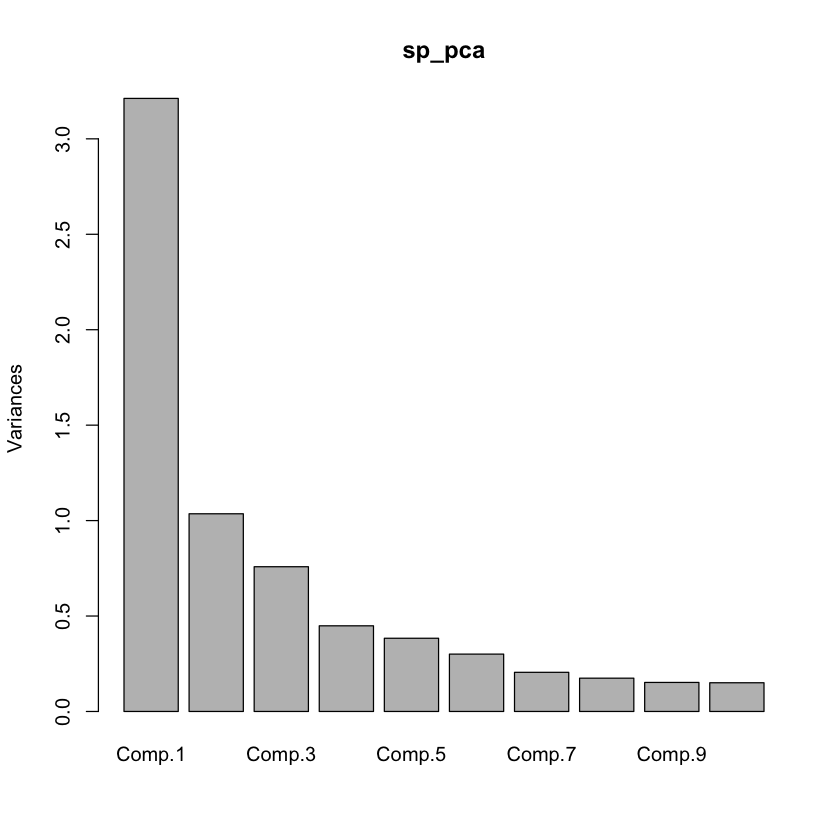

In [1]:
syms <- c("AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB",
  "COP", "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST")
top_sp <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(all_of(syms))
sp_pca <- princomp(top_sp)
screeplot(sp_pca)

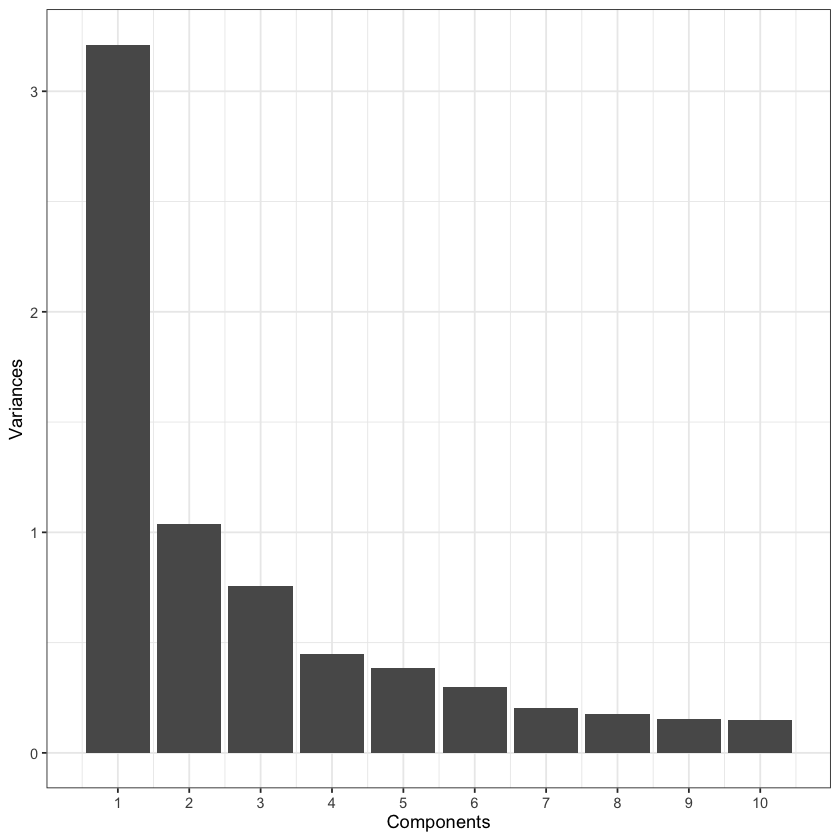

In [1]:
components <- 1:length(sp_pca$sdev)
g <- tibble(
  Components = components,
  Variances = sp_pca$sdev ** 2,
) |>
filter(
  Components < 11,
) |>
  ggplot(aes(x=Components, y=Variances)) +
    geom_bar(stat="identity") +
    coord_cartesian(xlim = c(0.5, 10.49)) +
    scale_x_continuous(breaks = components) +
    theme_bw()
g

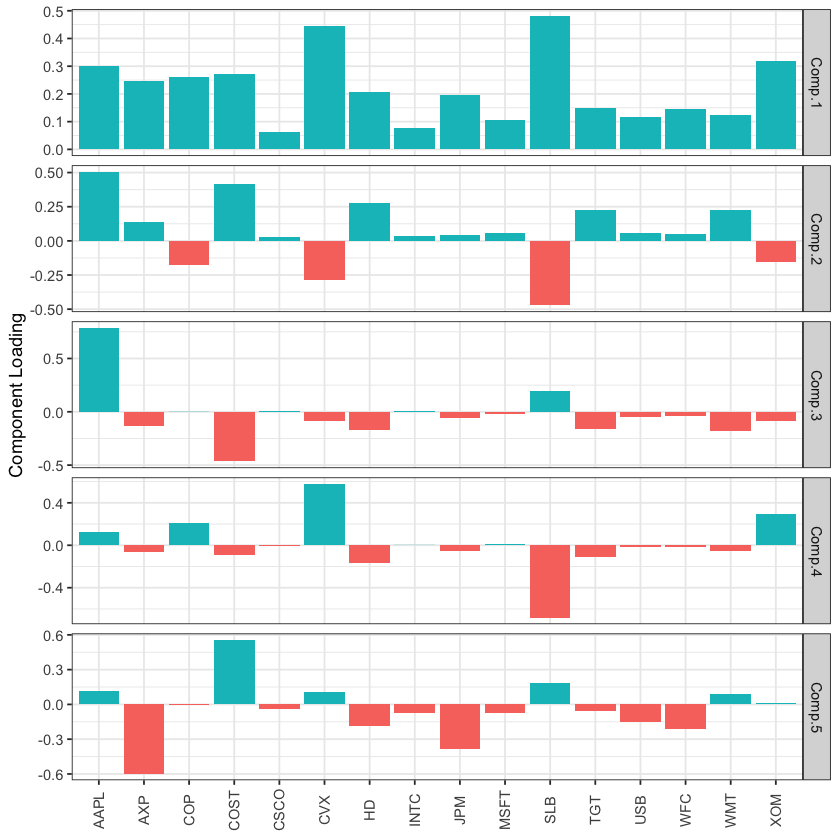

In [1]:
loadings <- sp_pca$loadings[, 1:5]
loadings <- as_tibble(loadings) %>%
  mutate(Symbol = row.names(loadings)) %>%
  pivot_longer(cols = starts_with("Comp"), names_to = "Component",
    values_to = "Weight") %>%
  mutate(color = Weight > 0)
ggplot(loadings, aes(x = Symbol, y = Weight, fill = color)) +
  geom_bar(stat = "identity") +
  facet_grid(Component ~ ., scales = "free_y") +
  guides(fill = "none") +
  labs(y = "Component Loading") +
  theme_bw() +
  theme(axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5))

#### Correspondence Analysis

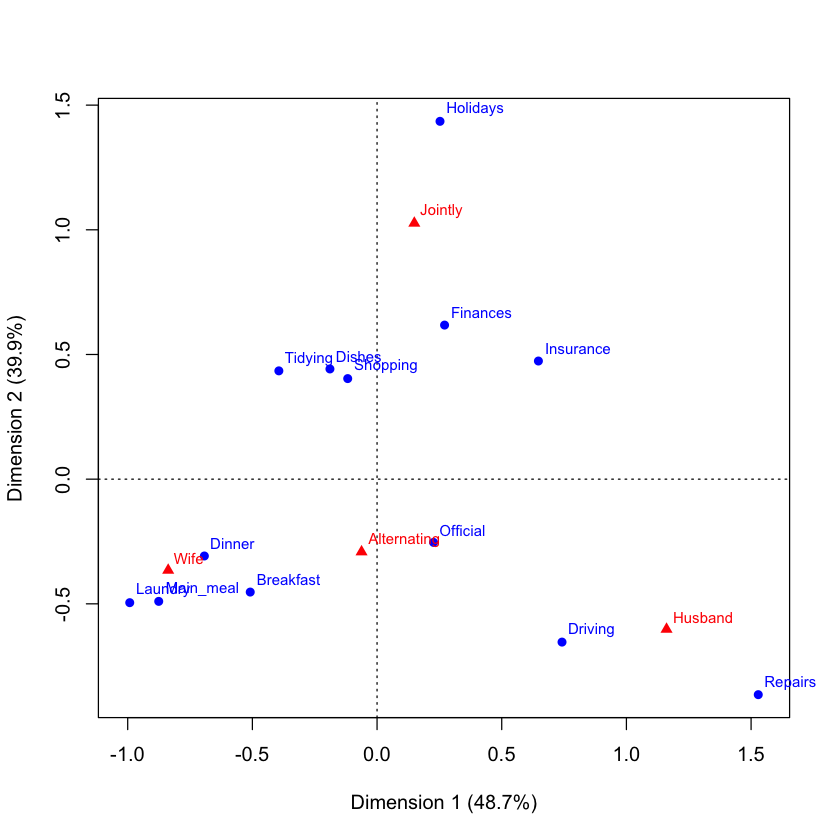

In [1]:
housetasks <- read_csv(file.path(DATA_DIR, "housetasks.csv"), show_col_types = FALSE) %>%
  column_to_rownames(var = "Task")
ca_analysis <- ca(housetasks)
plot(ca_analysis)

### K-Means Clustering
#### A Simple Example

In [1]:
df <- sp500_px %>%
  filter(Date >= "2011-01-01")
kmeans_wf <- workflow() %>%
  add_recipe(recipe(~ XOM + CVX, data = df)) %>%
  add_model(k_means(num_clusters = 4))
model <- kmeans_wf %>% fit(df)

In [1]:
augment(model, df) %>%
  select(Date, XOM, CVX, .pred_cluster) %>%
  head()

Date,XOM,CVX,.pred_cluster
<date>,<dbl>,<dbl>,<fct>
2011-01-03,0.73680496,0.2406809,Cluster_1
2011-01-04,0.16866845,-0.5845157,Cluster_2
2011-01-05,0.02663055,0.4469854,Cluster_1
2011-01-06,0.24855834,-0.9197513,Cluster_2
2011-01-07,0.33732892,0.1805111,Cluster_1
2011-01-10,0.00000000,-0.4641675,Cluster_2


In [1]:
tidy(model)

XOM,CVX,size,withinss,cluster
<dbl>,<dbl>,<int>,<dbl>,<fct>
0.3258460,0.4499705,469,122.54960,1
-0.2864216,-0.4929646,421,114.93724,2
1.0920721,1.5810766,123,85.15775,3
-1.1230447,-1.7188447,118,87.85587,4


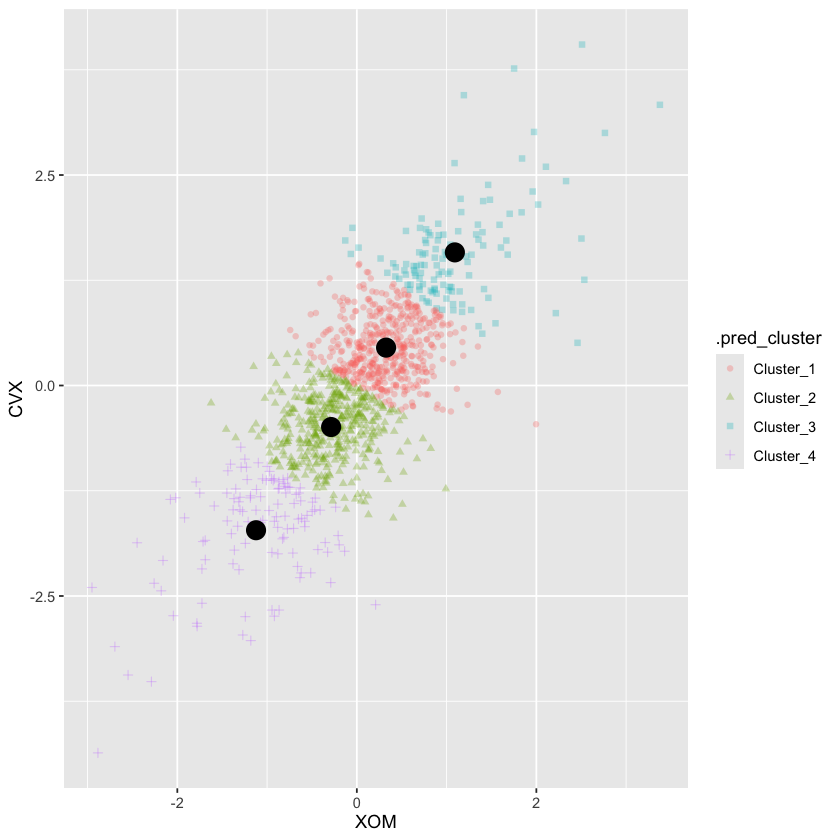

In [1]:
ggplot(augment(model, df), aes(x = XOM, y = CVX)) +
  geom_point(aes(color = .pred_cluster, shape = .pred_cluster), alpha = 0.3) +
  geom_point(data = tidy(model), aes(x = XOM, y = CVX), size = 3, stroke = 2)

#### K-Means Algorithm

In [1]:
syms <- c("AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB", "COP",
  "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST")
df <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(all_of(syms))
set.seed(10010)
kmeans_wf <- workflow() %>%
  add_recipe(recipe(~ ., data = df)) %>%
  add_model(k_means(num_clusters = 5) %>%
      set_engine("stats", nstart = 10))
km <- kmeans_wf %>% fit(df)

#### Interpreting the Clusters

In [1]:
tidy(km)$size

[1] 287 267 293 178 106

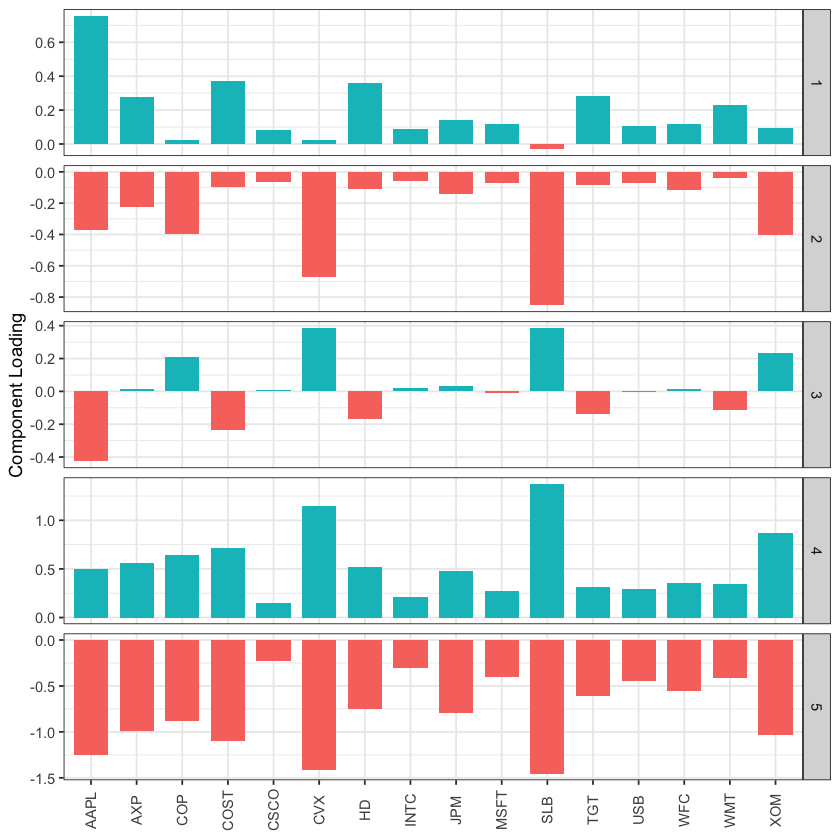

In [1]:
centers <- tidy(km) %>%
  pivot_longer(cols = all_of(syms), names_to = "Symbol",
    values_to = "Mean") %>%
  mutate(Color = Mean > 0)
ggplot(centers, aes(x = Symbol, y = Mean, fill = Color)) +
  geom_bar(stat = "identity", position = "identity", width = 0.75) +
  facet_grid(cluster ~ ., scales = "free_y") +
  guides(fill = "none") +
  labs(y = "Component Loading") +
  theme_bw() +
  theme(axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5))

#### Selecting the Number of Clusters

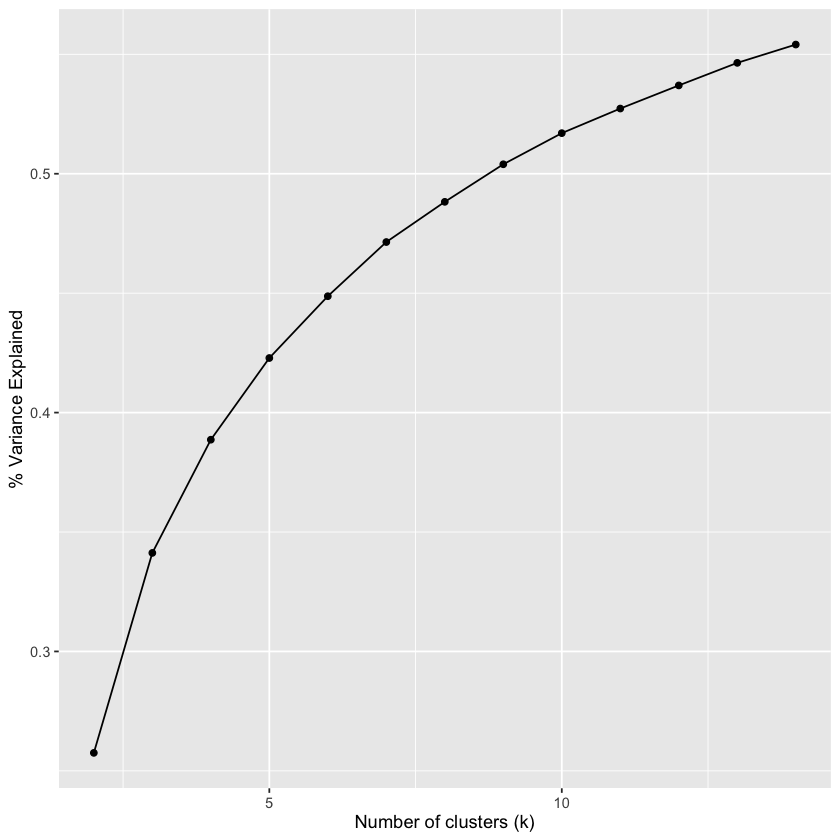

In [1]:
set.seed(10010)
train_kmeans <- function(num_clusters, data) {
  model <- workflow() %>%
    add_recipe(recipe(~ ., data = data)) %>%
    add_model(k_means(num_clusters = num_clusters) %>%
        set_engine("stats", nstart = 50, iter.max = 100)) %>%
    fit(data)
  return(model)
}
km <- train_kmeans(14, df)
totalss <- extract_fit_engine(km)$totss

pct_var <- tibble(pct_var = 0, num_clusters = 2:14)
for (num_clusters in 2:14) {
  km_cluster <- train_kmeans(num_clusters, df)
  pct_var[num_clusters - 1, "pct_var"] <- (
    extract_fit_engine(km_cluster)$betweenss / totalss)
}
ggplot(pct_var, aes(x = num_clusters, y = pct_var)) +
  geom_line() +
  geom_point() +
  labs(x = "Number of clusters (k)", y = "% Variance Explained")

### Hierarchical Clustering
#### A Simple Example

In [1]:
syms1 <- c("GOOGL", "AMZN", "AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB",
  "COP", "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST")
df <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(all_of(syms1)) %>%
  t() # take transpose: to cluster companies, we need the stocks along the rows

d <- dist(df)
hcl <- hclust(d)

#### The Dendrogram

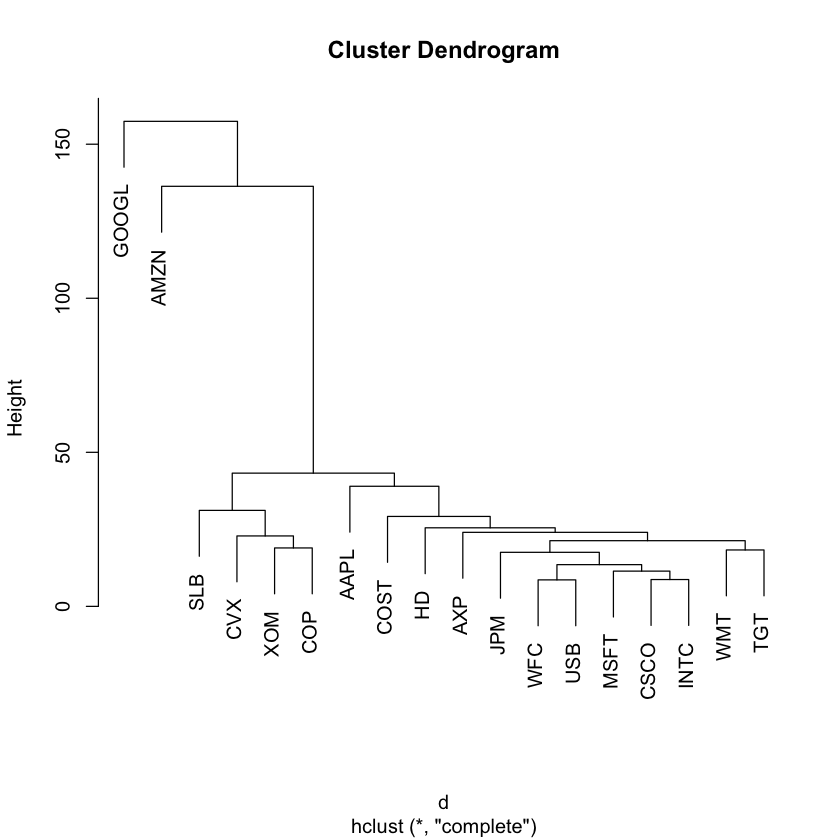

In [1]:
plot(hcl)

In [1]:
plot(hcl, ylab = "distance", xlab = "", sub = "", main = "")

agg_record_7d7f1e33a4da 
                      2

In [1]:
cutree(hcl, k = 4)

GOOGL  AMZN  AAPL  MSFT  CSCO  INTC   CVX   XOM   SLB   COP   JPM   WFC   USB 
    1     2     3     3     3     3     4     4     4     4     3     3     3 
  AXP   WMT   TGT    HD  COST 
    3     3     3     3     3

### Model-Based Clustering
#### Mixtures of Normals

In [1]:
df <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(c(XOM, CVX))
mcl <- Mclust(df)
summary(mcl)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEE (ellipsoidal, equal shape and orientation) model with 2 components: 

 log-likelihood    n df       BIC       ICL
      -2255.125 1131  9 -4573.528 -5075.657

Clustering table:
  1   2 
168 963 

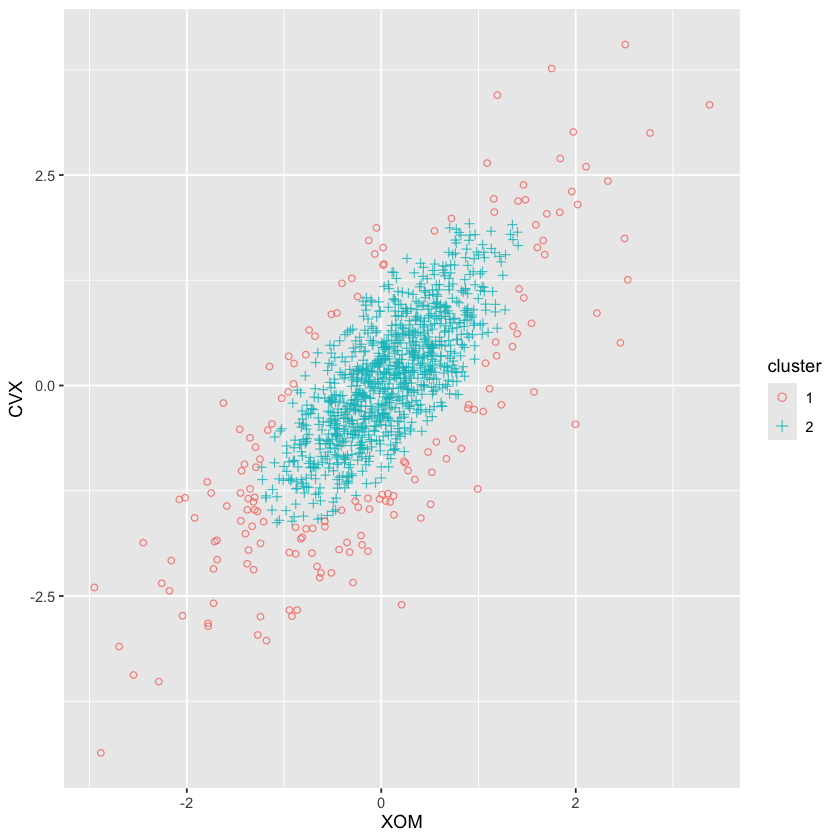

In [1]:
cluster <- factor(predict(mcl)$classification)
ggplot(df, aes(x = XOM, y = CVX, color = cluster, shape = cluster)) +
  geom_point(alpha = 0.8) +
  scale_shape_manual(
    values = c(1, 3),
    guide = guide_legend(override.aes = aes(size = 2)))

In [1]:
summary(mcl, parameters = TRUE)$mean

XOM,-0.04362218,0.05792282
CVX,-0.21109525,0.07375447


In [1]:
summary(mcl, parameters = TRUE)$variance

, , 1

         XOM      CVX
XOM 1.044671 1.065190
CVX 1.065190 1.912748

, , 2

          XOM       CVX
XOM 0.2998935 0.3057838
CVX 0.3057838 0.5490920

#### Selecting the Number of Clusters

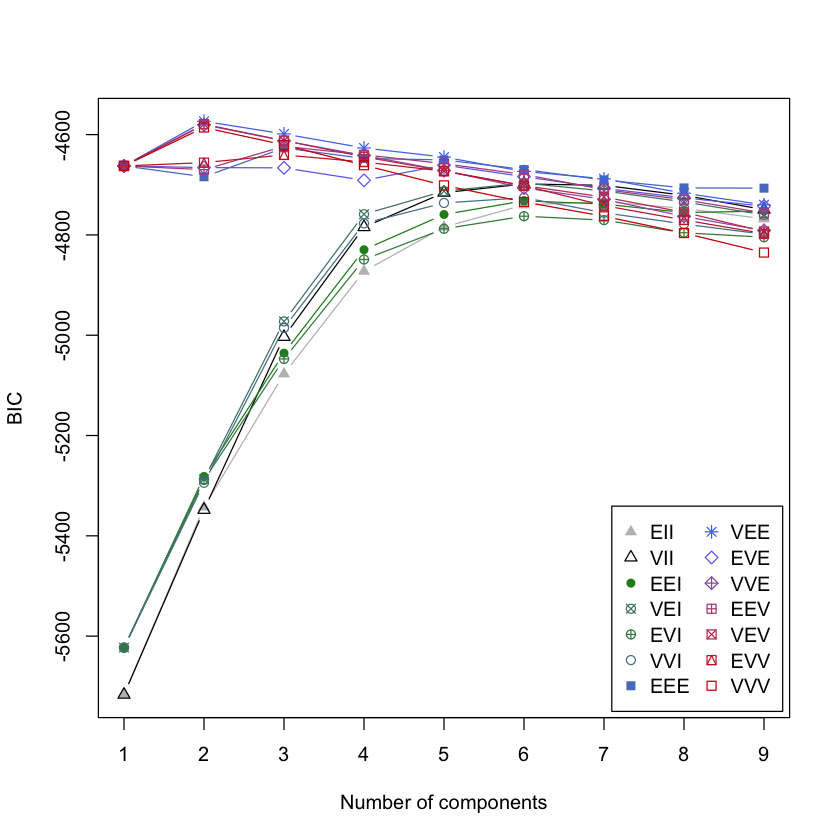

In [1]:
plot(mcl, what = "BIC", ask = FALSE)

In [1]:
plot(mcl, what = "BIC", ask = FALSE)

agg_record_7d7f350fcbfb 
                      2

### Scaling and Categorical Variables
#### Scaling the Variables

In [1]:
loan_data <- read_csv(file.path(DATA_DIR, "loan_data.csv.gz"), show_col_types = FALSE) %>%
  mutate(
    across(where(is.character), as.factor),
    outcome = factor(outcome, levels = c("paid off", "default"))
  )
defaults <- loan_data %>%
  filter(outcome == "default") %>%
  select(c(loan_amnt, annual_inc, revol_bal, open_acc, dti, revol_util))
km <- kmeans(defaults, centers = 4, nstart = 10)
centers <- data.frame(size = km$size, km$centers)
round(centers, digits = 2)

,size,loan_amnt,annual_inc,revol_bal,open_acc,dti,revol_util
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,13819,10577.04,42380.98,10245.27,9.58,17.71,58.09
2,1221,21797.26,164503.32,38652.54,12.61,13.53,63.65
3,7579,18247.71,83069.61,19587.30,11.66,16.79,62.26
4,52,22570.19,489783.40,85161.35,13.33,6.91,59.65


In [1]:
df0 <- scale(df)
km0 <- kmeans(df0, centers = 4, nstart = 10)
centers0 <- scale(km0$centers, center = FALSE,
  scale = 1 / attr(df0, "scaled:scale"))
centers0 <- scale(centers0, center = -attr(df0, "scaled:center"),
  scale = FALSE)
centers0 <- data.frame(size = km0$size, centers0)
round(centers0, digits = 2)

,size,XOM,CVX
,<dbl>,<dbl>,<dbl>
1,131,1.17,1.45
2,420,-0.29,-0.44
3,450,0.33,0.45
4,130,-1.13,-1.62


#### Dominant Variables

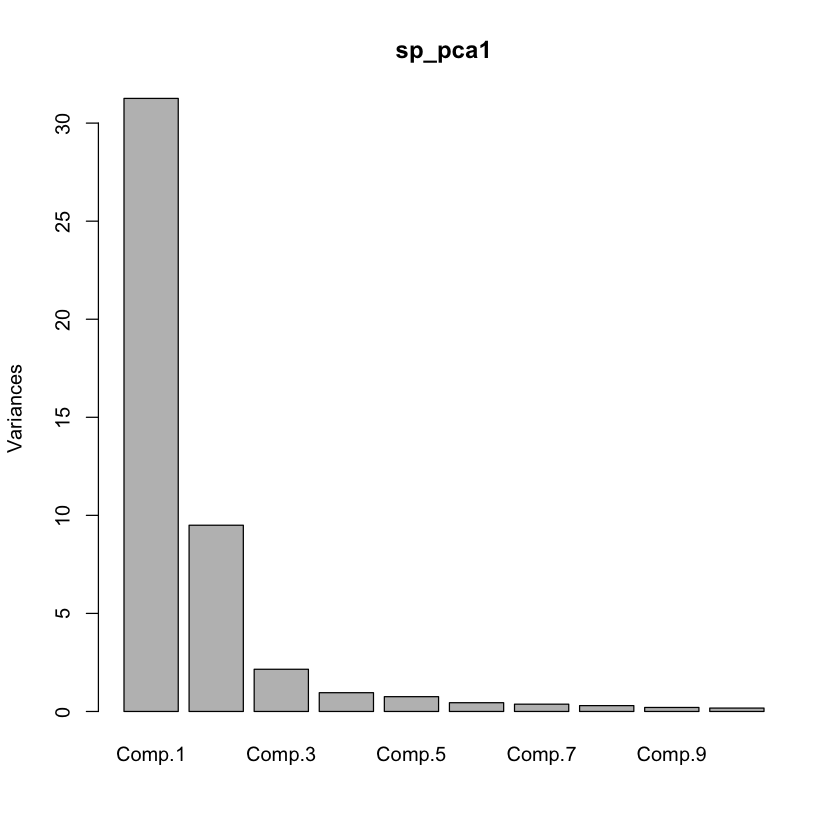

In [1]:
syms <- c("GOOGL", "AMZN", "AAPL", "MSFT", "CSCO", "INTC", "CVX", "XOM", "SLB",
  "COP", "JPM", "WFC", "USB", "AXP", "WMT", "TGT", "HD", "COST")
top_sp1 <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(all_of(syms))
sp_pca1 <- princomp(top_sp1)
screeplot(sp_pca1)

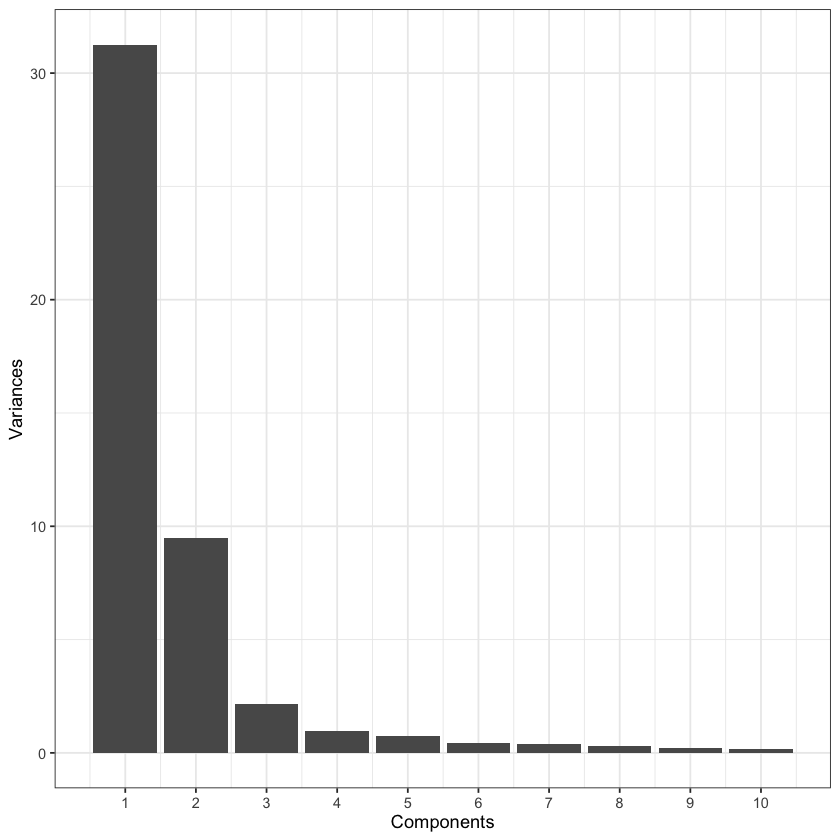

In [1]:
components <- 1:length(sp_pca1$sdev)
g <- tibble(
  Components = components,
  Variances = sp_pca1$sdev ** 2,
) |>
filter(
  Components < 11,
) |>
  ggplot(aes(x=Components, y=Variances)) +
    geom_bar(stat="identity") +
    coord_cartesian(xlim = c(0.5, 10.49)) +
    scale_x_continuous(breaks = components) +
    theme_bw()
g

In [1]:
round(sp_pca1$loadings[, 1:2], 3)

,Comp.1,Comp.2
GOOGL,0.781,0.609
AMZN,0.593,-0.792
AAPL,0.078,0.004
MSFT,0.029,0.002
CSCO,0.017,-0.001
INTC,0.020,-0.001
CVX,0.068,-0.021
XOM,0.053,-0.005
SLB,0.079,-0.013
COP,0.044,-0.016


#### Categorical Data and Gower's Distance

In [1]:
x <- loan_data[1:5, c("dti", "payment_inc_ratio", "home_", "purpose_")]
x

dti,payment_inc_ratio,home_,purpose_
<dbl>,<dbl>,<fct>,<fct>
1.00,2.39320,RENT,major_purchase
5.55,4.57170,OWN,small_business
18.08,9.71600,RENT,other
10.08,12.21520,RENT,debt_consolidation
7.06,3.90888,RENT,other


In [1]:
daisy(x, metric = "gower")

Dissimilarities :
          1         2         3         4
2 0.6220479                              
3 0.6863877 0.8143398                    
4 0.6329040 0.7608561 0.4307083          
5 0.3772789 0.5389727 0.3091088 0.5056250

Metric :  mixed ;  Types = I, I, N, N 
Number of objects : 5

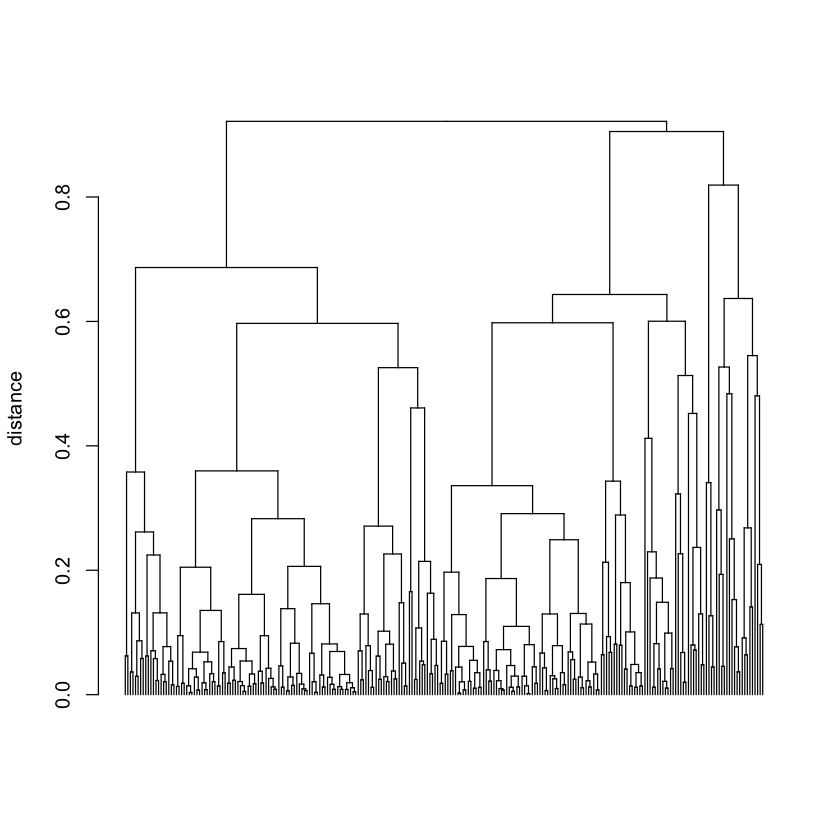

In [1]:
set.seed(1234)
defaults <- loan_data %>%
  filter(outcome == "default")
df <- defaults[sample(nrow(defaults), 250),
  c("dti", "payment_inc_ratio", "home_", "purpose_")]
d <- daisy(df, metric = "gower")
hcl <- hclust(d)
dnd <- as.dendrogram(hcl)
plot(dnd, leaflab = "none", ylab = "distance")

In [1]:
plot(dnd, leaflab = "none", ylab = "distance")

agg_record_7d7ff2b1536 
                     2

In [1]:
dnd_cut <- cut(dnd, h = 0.5)
df[labels(dnd_cut$lower[[1]]), ]

dti,payment_inc_ratio,home_,purpose_
<dbl>,<dbl>,<fct>,<fct>
3.61,3.60224,RENT,other
0.00,0.71100,RENT,other
25.50,13.99780,RENT,other
28.44,12.78840,RENT,other
25.36,4.06295,RENT,other
25.23,6.35079,RENT,other
27.50,9.74914,RENT,other
30.10,6.60667,RENT,other
16.36,12.01650,RENT,other


#### Problems with Clustering Mixed Data

In [1]:
df <- model.matrix(~ -1 + dti + payment_inc_ratio + home_ + pub_rec_zero,
  data = defaults)
df0 <- scale(df)
km0 <- kmeans(df0, centers = 4, nstart = 10)
centers0 <- scale(km0$centers, center = FALSE,
  scale = 1 / attr(df0, "scaled:scale"))
round(scale(centers0, center = - attr(df0, "scaled:center"), scale = FALSE), 2)

,dti,payment_inc_ratio,home_MORTGAGE,home_OWN,home_RENT,pub_rec_zero
1,17.20,9.27,0.00,1,0.00,0.92
2,17.46,8.42,1.00,0,0.00,1.00
3,16.99,9.11,0.00,0,1.00,1.00
4,16.50,8.06,0.52,0,0.48,0.00


# Supplementary Material
## Figure 7-4. Graphical representation of a correspondence analysis of house task data

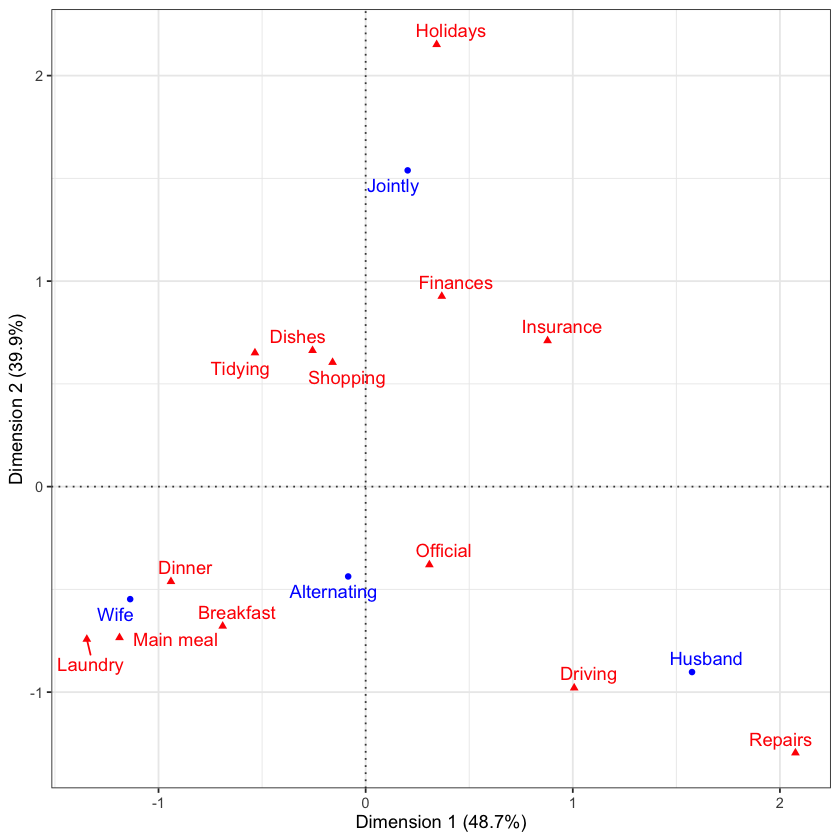

In [1]:
set.seed(1234)
contrib <- ca_analysis$sv ** 2
contrib <- contrib / sum(contrib)
colcoord <- as.data.frame(ca_analysis$colcoord)
rowcoord <- as.data.frame(ca_analysis$rowcoord)
coords <- bind_rows(
  rowcoord %>% mutate(type = "rowcoord"),
  colcoord %>% mutate(type = "columns")
)
row.names(coords) <- gsub("_", " ", row.names(coords))

graph <- ggplot(coords, aes(x = Dim1, y = Dim2, color = type,
    label = rownames(coords), shape = type)) +
  geom_hline(yintercept = 0, linetype = "dotted", color = "#444444") +
  geom_vline(xintercept = 0, linetype = "dotted", color = "#444444") +
  geom_point() +
  geom_text_repel() +
  xlab(sprintf("Dimension 1 (%.1f%%)", 100 * contrib[1])) +
  ylab(sprintf("Dimension 2 (%.1f%%)", 100 * contrib[2])) +
  scale_color_manual(values = c("blue", "red")) +
  theme_bw() +
  theme(legend.position = "none")
graph

## Figure 7-5. The clusters of K-means applied to daily stock returns for ExxonMobil and Chevron

Warning message:
“`as.tibble()` was deprecated in tibble 2.0.0.
ℹ Please use `as_tibble()` instead.
ℹ The signature and semantics have changed, see `?as_tibble`.”


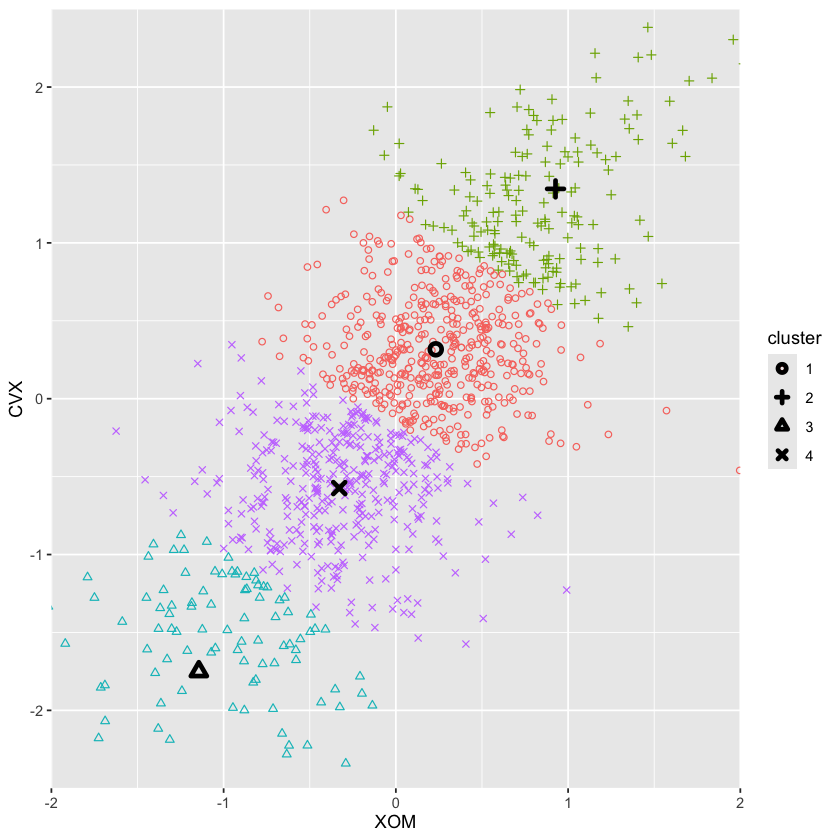

In [1]:
set.seed(1010103)
df <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(XOM, CVX)
km <- kmeans(df, centers = 4, nstart = 1)
df <- df %>% mutate(cluster = factor(km$cluster))
centers <- as.tibble(km$centers) %>%
  mutate(cluster = factor(1:4))

ggplot(df, aes(x = XOM, y = CVX, color = cluster, shape = cluster)) +
  geom_point() +
  scale_shape_manual(
    values = c(1, 3, 2, 4),
    guide = guide_legend(override.aes = aes(size = 1))
  ) +
  geom_point(data = centers, aes(x = XOM, y = CVX), size = 2, stroke = 2, color = "black") +
  coord_cartesian(xlim = c(-2, 2), ylim = c(-2.5, 2.5)) +
  scale_x_continuous(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0))

## Figure 7-9. A comparison of measures of dissimilarity applied to stock data

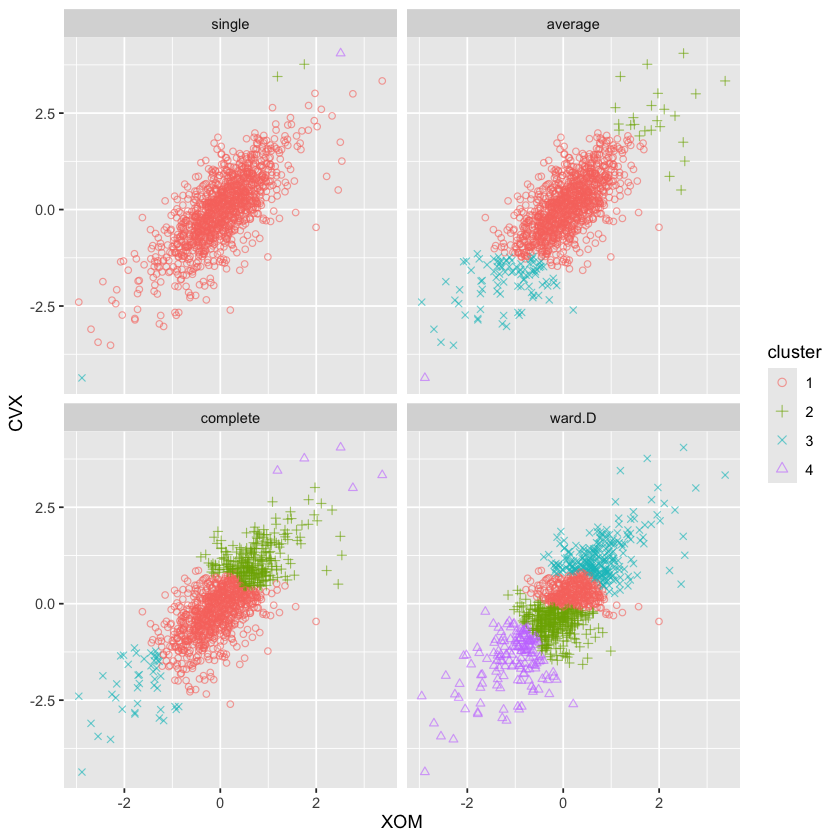

In [1]:
cluster_fun <- function(df, method) {
  d <- dist(df)
  hcl <- hclust(d, method = method)
  tree <- cutree(hcl, k = 4)
  return(df %>% mutate(cluster = factor(tree), method = method))
}

df0 <- sp500_px %>%
  filter(Date >= "2011-01-01") %>%
  select(XOM, CVX)
df <- bind_rows(
  cluster_fun(df0, method = "single"),
  cluster_fun(df0, method = "average"),
  cluster_fun(df0, method = "complete"),
  cluster_fun(df0, method = "ward.D")
)
df$method <- ordered(df$method, c("single", "average", "complete", "ward.D"))

graph <- ggplot(data = df, aes(x = XOM, y = CVX, color = cluster, shape = cluster)) +
  geom_point(alpha = 0.6) +
  scale_shape_manual(
    values = c(1, 3, 4, 2),
    guide = guide_legend(override.aes = aes(size = 2))
  ) +
  facet_wrap(~ method)
graph

## Figure 7-10. Probability contours for a two-dimensional normal distribution

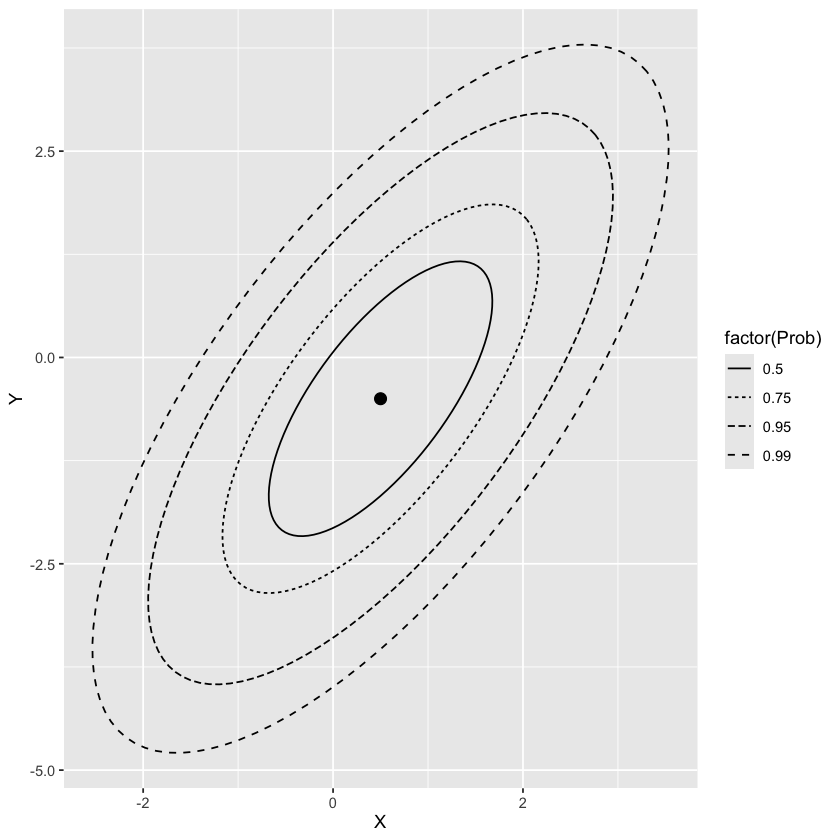

In [1]:
mu <- c(0.5, -0.5)
sigma <- matrix(c(1, 1, 1, 2), nrow = 2)
prob <- c(0.5, 0.75, 0.95, 0.99) ## or whatever you want
names(prob) <- prob ## to get id column in result
df <- tibble()
for (p in prob){
  df <- bind_rows(
    df,
    as.tibble(ellipse(x = sigma, centre = mu, level = p)) %>%
      mutate(prob = p)
  )
}
names(df) <- c("X", "Y", "Prob")

## Figure 7-9: Multivariate normal ellipses
dfmu <- tibble(X = mu[1], Y = mu[2])

graph <- ggplot(df, aes(X, Y)) +
  geom_path(aes(linetype = factor(Prob))) +
  geom_point(data = dfmu, aes(X, Y), size = 3)
graph